In [ ]:
pip install prophet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import plotly.graph_objects as go

plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported ✅")

Libraries imported ✅


In [3]:
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape:", df.shape)
print("Date Range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())

Shape: (776577, 15)
Date Range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [4]:
# Prophet needs exactly 2 columns: ds (date) and y (value)

monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly.columns = ['ds', 'y']
monthly['ds'] = monthly['ds'].dt.to_timestamp()

print("Monthly Revenue Table:")
print(f"Total months: {len(monthly)}")
print(monthly)

Monthly Revenue Table:
Total months: 25
           ds           y
0  2009-12-01   677916.07
1  2010-01-01   533712.98
2  2010-02-01   497937.57
3  2010-03-01   665973.67
4  2010-04-01   585127.43
5  2010-05-01   592734.13
6  2010-06-01   628809.40
7  2010-07-01   581487.96
8  2010-08-01   594561.17
9  2010-09-01   805544.81
10 2010-10-01  1011556.75
11 2010-11-01  1155978.39
12 2010-12-01   565199.56
13 2011-01-01   562682.91
14 2011-02-01   442293.59
15 2011-03-01   583143.85
16 2011-04-01   454440.88
17 2011-05-01   659242.49
18 2011-06-01   653264.92
19 2011-07-01   591603.79
20 2011-08-01   635514.38
21 2011-09-01   938752.63
22 2011-10-01  1002326.56
23 2011-11-01  1136534.00
24 2011-12-01   512228.08


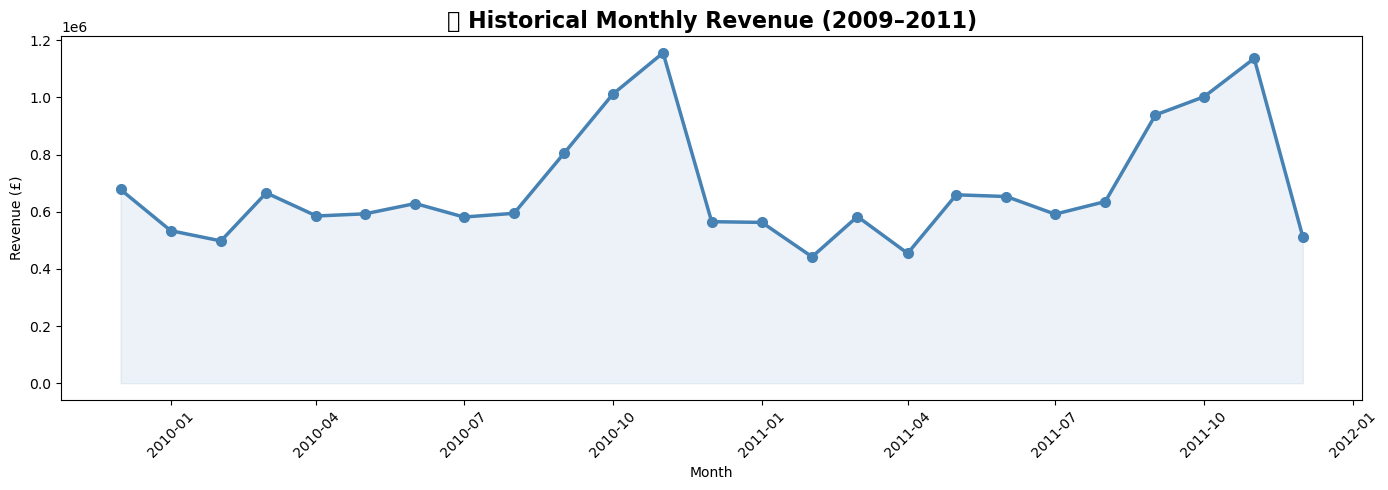

📌 Min Revenue Month: £442,293.59
📌 Max Revenue Month: £1,155,978.39
📌 Avg Monthly Revenue: £682,742.72


In [5]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['ds'], monthly['y'], 
         marker='o', color='steelblue', 
         linewidth=2.5, markersize=7)
plt.fill_between(monthly['ds'], monthly['y'], 
                 alpha=0.1, color='steelblue')
plt.title('📈 Historical Monthly Revenue (2009–2011)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/19_historical_revenue.png', dpi=150)
plt.show()

print(f"📌 Min Revenue Month: £{monthly['y'].min():,.2f}")
print(f"📌 Max Revenue Month: £{monthly['y'].max():,.2f}")
print(f"📌 Avg Monthly Revenue: £{monthly['y'].mean():,.2f}")

# How Prophet Works

Prophet breaks your data into 3 parts:

1. TREND     → Is revenue going up or down overall?
2. SEASONALITY → Does revenue spike every November? 
                 Does it dip every January?
3. FORECAST  → Combines trend + seasonality 
               to predict future values

It also gives you:
- Predicted value (yhat)        → most likely revenue
- Upper bound (yhat_upper)      → best case scenario
- Lower bound (yhat_lower)      → worst case scenario

This is called a CONFIDENCE INTERVAL.

In [6]:
# Initialize Prophet
model = Prophet(
    yearly_seasonality=True,   # capture yearly patterns
    weekly_seasonality=False,  # monthly data — no weekly pattern
    daily_seasonality=False,   # monthly data — no daily pattern
    seasonality_mode='multiplicative',  # good for retail data
    interval_width=0.95        # 95% confidence interval
)

# Train the model
model.fit(monthly)

print("✅ Prophet model trained!")
print(f"Trained on {len(monthly)} months of data")

20:06:39 - cmdstanpy - INFO - Chain [1] start processing
20:06:40 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained!
Trained on 25 months of data


In [7]:
# Create next 3 months to forecast
future = model.make_future_dataframe(
    periods=3,
    freq='MS'  # MS = Month Start
)

print("Future dates created:")
print(future.tail(5))

# Generate forecast
forecast = model.predict(future)

print("\nForecast columns:", forecast.columns.tolist())
print("\nForecast preview:")
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(5)

Future dates created:
           ds
23 2011-11-01
24 2011-12-01
25 2012-01-01
26 2012-02-01
27 2012-03-01

Forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yhat']

Forecast preview:


,ds,yhat,yhat_lower,yhat_upper
23,2011-11-01,1.136619e+06,1.123219e+06,1.149629e+06
24,2011-12-01,5.248987e+05,5.121866e+05,5.381399e+05
25,2012-01-01,6.902098e+05,6.770081e+05,7.037065e+05
26,2012-02-01,4.628027e+05,4.494474e+05,4.767142e+05
27,2012-03-01,6.387038e+05,6.215264e+05,6.560279e+05


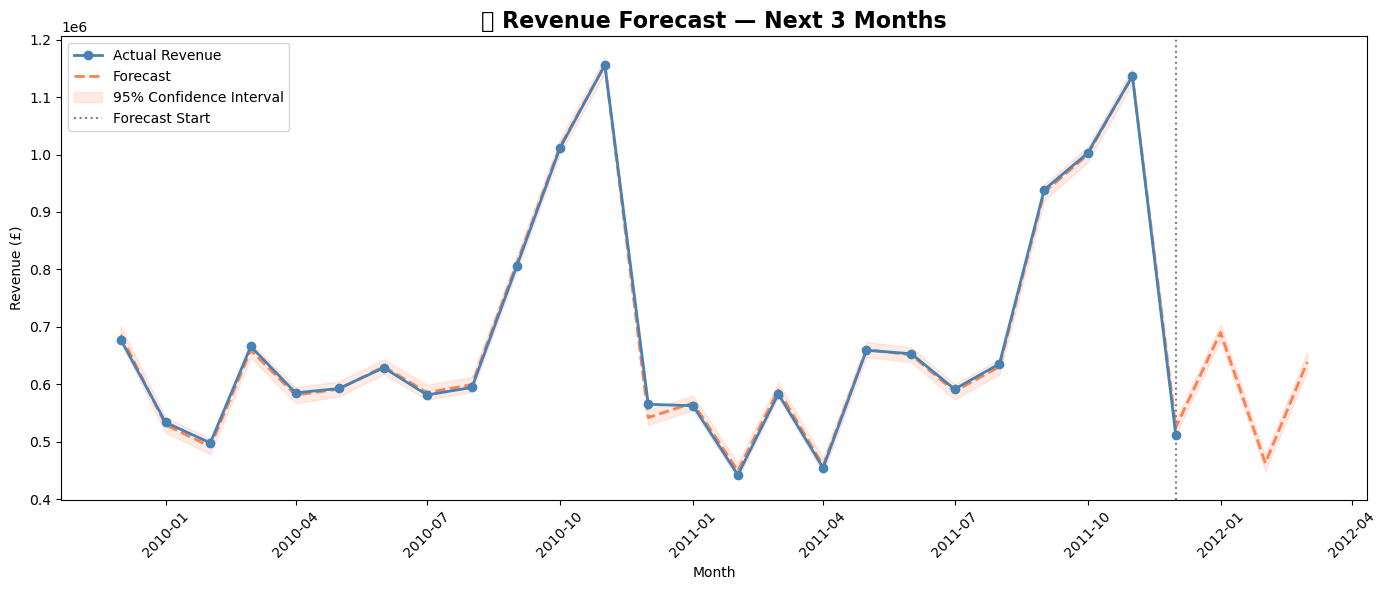

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(monthly['ds'], monthly['y'],
        color='steelblue', marker='o',
        linewidth=2, markersize=6,
        label='Actual Revenue', zorder=5)

# Forecasted values
forecast_only = forecast[forecast['ds'] > monthly['ds'].max()]
ax.plot(forecast['ds'], forecast['yhat'],
        color='coral', linewidth=2,
        linestyle='--', label='Forecast')

# Confidence interval
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.15, color='coral',
                label='95% Confidence Interval')

# Mark forecast start
ax.axvline(x=monthly['ds'].max(),
           color='gray', linestyle=':', linewidth=1.5,
           label='Forecast Start')

ax.set_title('📈 Revenue Forecast — Next 3 Months',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/20_forecast.png', dpi=150)
plt.show()

In [9]:
# Show just the forecasted months
future_forecast = forecast[forecast['ds'] > monthly['ds'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].reset_index(drop=True)

future_forecast.columns = ['Month', 'Predicted', 'Worst Case', 'Best Case']
future_forecast['Month'] = future_forecast['Month'].dt.strftime('%B %Y')
future_forecast[['Predicted','Worst Case','Best Case']] = \
    future_forecast[['Predicted','Worst Case','Best Case']].round(2)

print("📊 3 Month Revenue Forecast:")
print(future_forecast.to_string(index=False))

📊 3 Month Revenue Forecast:
        Month  Predicted  Worst Case  Best Case
 January 2012  690209.83   677008.14  703706.52
February 2012  462802.69   449447.45  476714.17
   March 2012  638703.81   621526.40  656027.94


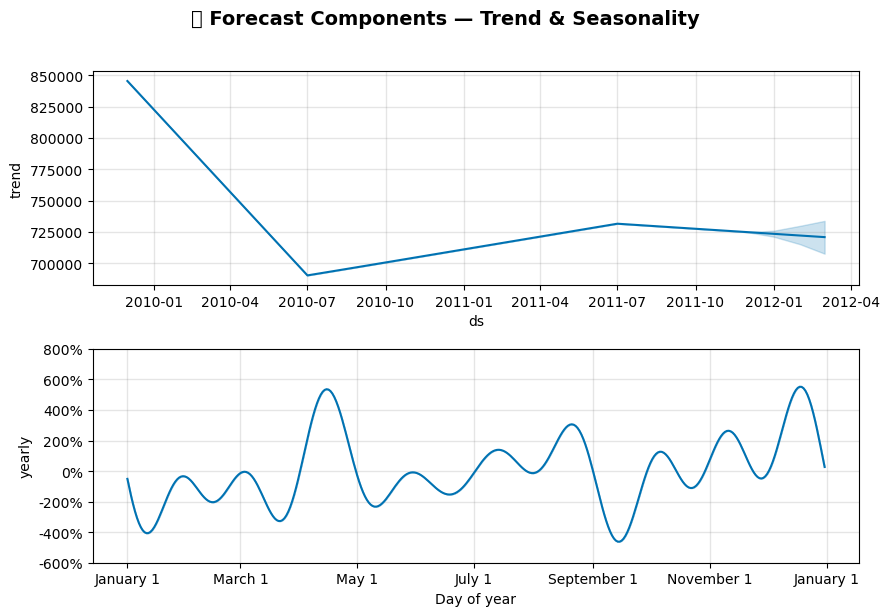

In [10]:
# This shows WHY Prophet made these predictions
fig = model.plot_components(forecast)
plt.suptitle('📊 Forecast Components — Trend & Seasonality',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/21_components.png', dpi=150)
plt.show()

In [11]:
avg_actual   = monthly['y'].mean()
avg_forecast = future_forecast['Predicted'].mean()
growth       = ((avg_forecast - avg_actual) / avg_actual * 100).round(2)

print("=" * 55)
print("📈 FORECASTING SUMMARY")
print("=" * 55)
print(f"Historical Months    : {len(monthly)}")
print(f"Months Forecasted    : 3")
print(f"Avg Monthly Revenue  : £{avg_actual:,.2f}")
print(f"\n📊 3 Month Forecast:")
print(future_forecast.to_string(index=False))
print(f"\n📈 Forecasted Growth vs Historical Avg: {growth}%")
print("=" * 55)
print("\n✅ Forecasting Complete!")

📈 FORECASTING SUMMARY
Historical Months    : 25
Months Forecasted    : 3
Avg Monthly Revenue  : £682,742.72

📊 3 Month Forecast:
        Month  Predicted  Worst Case  Best Case
 January 2012  690209.83   677008.14  703706.52
February 2012  462802.69   449447.45  476714.17
   March 2012  638703.81   621526.40  656027.94

📈 Forecasted Growth vs Historical Avg: -12.52%

✅ Forecasting Complete!


In [12]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    'C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/forecast_results.csv', index=False
)
print("✅ Forecast saved!")

✅ Forecast saved!
